In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates #to customize x-axis to remove year from tick labels
import colormaps as cmaps

import uxarray as ux

import bottleneck as bn

import cartopy.crs as ccrs
import geoviews.feature as gf

import warnings
warnings.filterwarnings("ignore")

In [2]:
sys.path.append("/global/common/software/m1867/python/ksa_env")
from ks_pkg.plot_settings import init_style  #default plt setting and font

# (Make sure 'Arial.ttf' and 'journal.mplstyle' are in the folder)
init_style()

loading ks_pkg module in /global/common/software/m1867/python/ksa_env/ks_pkg ks_pkg
Successfully loaded font: Arial


In [3]:
# 1. Open the Grid File
# UXarray automatically detects the Exodus II format
grid_file = "scrip_DPSCREAM_RCE_dx1km_600x600km.nc"

uxgrid = ux.open_grid(grid_file)

In [4]:
# 2. Verify the size
# It should report n_face = 160,000 (which matches your ncol)
print(f"Grid loaded: {uxgrid.n_face} faces (physics columns)")

Grid loaded: 160000 faces (physics columns)


In [5]:
# 3. Plot the Grid
# Since the coordinates are now in Degrees (approx -2 to +2), 
# the plotting engine handles them natively without crashing.
#uxgrid.plot(backend='matplotlib')
uxgrid.plot.points()

#plt.title("DP-SCREAM Physics Grid (600x600 km)")
#plt.show()

:Points   [lon,lat]

simulation data


In [13]:
uxgrid

<uxarray.Grid>
Original Grid Type: Scrip
Grid Dimensions:
  * n_node: 160801
  * n_face: 160000
  * n_max_face_nodes: 4
Grid Coordinates (Spherical):
  * node_lon: (160801,)
  * node_lat: (160801,)
  * face_lon: (160000,)
  * face_lat: (160000,)
Grid Coordinates (Cartesian):
Grid Connectivity Variables:
  * face_node_connectivity: (160000, 4)
Grid Descriptor Variables:

In [6]:
face_lon = uxgrid.face_lon.values
face_lat = uxgrid.face_lat.values

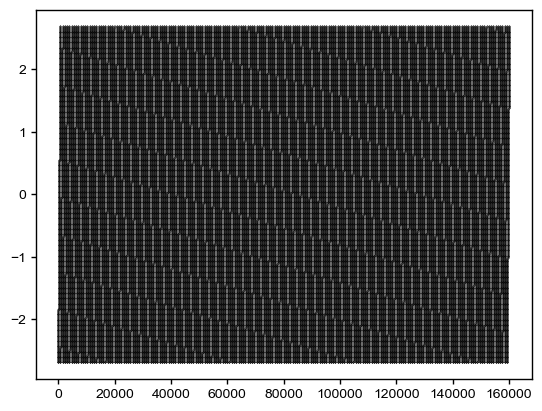

In [7]:
plt.plot(face_lon, 'k.', markersize=0.5)
plt.show()

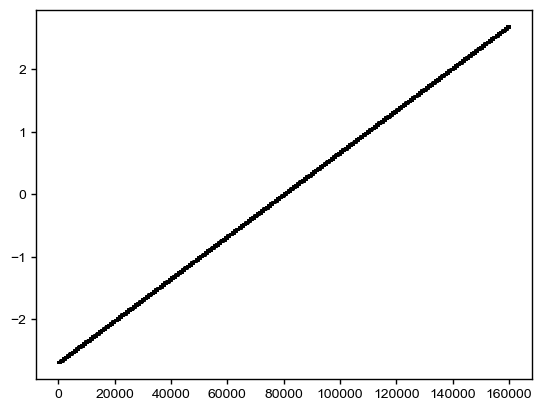

In [8]:
plt.plot(face_lat, 'k.', markersize=0.5)
plt.show()

In [10]:
# --- File Paths ---
# 1. The Grid File (created in the previous step)
grid_file = "scrip_DPSCREAM_RCE_dx1km_600x600km.nc"


# 2. The Simulation Data File
data_file = "scream_gpu_dpxx_RCE_dx1km.fullfield.AVERAGE.nhours_x1.2000-01-01-00000.nc"

In [11]:
uxds = ux.open_dataset(grid_file, data_file)

In [12]:
# --- Sanity Check ---
# Verify that T_2m was loaded and linked to the grid (n_face)
print("Variable Dimensions:", uxds['T_2m'].dims)
print(uxds['T_2m'])

Variable Dimensions: ('time', 'n_face')
<xarray.UxDataArray 'T_2m' (time: 22, n_face: 160000)> Size: 14MB
[3520000 values with dtype=float32]
Coordinates:
  * time     (time) object 176B 2000-01-01 01:00:00 ... 2000-01-01 22:00:00
    lat      (n_face) float32 640kB ...
    lon      (n_face) float32 640kB ...
Dimensions without coordinates: n_face
Attributes:
    units:                    K
    averaging_count_tracker:  avg_count_ncol
    long_name:                2 meter air temperature
    standard_name:            air_temperature
    cell_methods:             time: mean


In [17]:
# --- Visualization ---
# 1. Select the Time Step
# T_2m has dimensions (time, ncol). We must select one time slice to plot a 2D map.
# .isel(time=-1) selects the last time step.
t2m_last = uxds['T_2m'].isel(time=12)

:Image   [x,y]   (x_y T_2m)
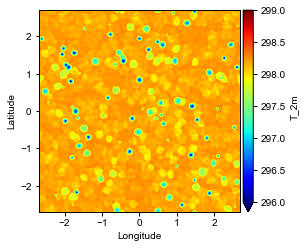

Text(0.5, 1.0, '2m Temperature (Last Time Step)')

In [18]:
# 2. Plot
# Note: We use the 'matplotlib' backend for safety on standard clusters
# 'aspect=1' ensures pixels are square (helpful for planar grids)
t2m_last.plot(backend='matplotlib', cmap='jet', aspect=1, clim=(296, 299))  #min_px=296, max_px=299

plt.title("2m Temperature (Last Time Step)")
plt.show()

In [12]:
uxds.close()
del uxds